<a href="https://colab.research.google.com/github/parthasarathipanda2006/Projects/blob/main/GNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tqdm import tqdm

#Import Emnist Dataset

In [ ]:

(x_train_full, y_train_full), _ = keras.datasets.mnist.load_data()
x_train_processed = (x_train_full.reshape(-1, 28, 28, 1).astype('float32')-127.5)/127.5
BUFFER_SIZE=60000
BATCH_SIZE=128
dataset = tf.data.Dataset.from_tensor_slices(x_train_processed).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


#Generator

In [ ]:
class Generator(keras.Model):
  def __init__(self):
    super(Generator,self).__init__()
    self.Dense=layers.Dense(7*7*128,use_bias=False)
    self.bn1=layers.BatchNormalization()
    self.bn2=layers.BatchNormalization()
    self.bn3=layers.BatchNormalization()
    self.upconv1=layers.Conv2DTranspose(64,(4,4),strides=(2,2),padding='same',use_bias=False)
    self.upconv2=layers.Conv2DTranspose(64,(4,4),strides=(2,2),padding='same',use_bias=False)
    self.output_conv=layers.Conv2DTranspose(1,(3,3),padding='same',use_bias=False)
  def call(self,input_tensor):
    x=self.Dense(input_tensor)
    x=self.bn1(x)
    x=tf.nn.relu(x)
    x=tf.reshape(x,(-1,7,7,128))
    x=self.upconv1(x)
    x=self.bn2(x)
    x=tf.nn.relu(x)
    x=self.upconv2(x)
    x=self.bn3(x)
    x=tf.nn.relu(x)
    x=self.output_conv(x)
    x=tf.nn.tanh(x)
    return x

In [ ]:
generator=Generator()
dummy_input = tf.random.normal([1, 100])
generator(dummy_input)
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (1, 6272)              │       627,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (1, 6272)              │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (1, 14, 14, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (1, 28, 28, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (1, 14, 14, 64)        │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (1, 28, 28, 64)        │        65,536 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (1, 28, 28, 1)         │           576 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 849,984 (3.24 MB)

 Trainable params: 837,184 (3.19 MB)

 Non-trainable params: 12,800 (50.00 KB)

#Discriminator

In [ ]:
class Discremenator(keras.Model):
  def __init__(self):
    super(Discremenator,self).__init__()
    self.conv1=layers.Conv2D(64,kernel_size=4,strides=2,padding='same')
    self.conv2=layers.Conv2D(128,kernel_size=4,strides=2,padding='same')
    self.bn1=layers.BatchNormalization()
    self.Dense1=layers.Dense(10,activation='relu')
    self.Dense2=layers.Dense(1)

  def call(self,input_tensor):
    x=self.conv1(input_tensor)
    x=tf.nn.leaky_relu(x,alpha=0.2)
    x=self.conv2(x)
    x=self.bn1(x)
    x=tf.nn.leaky_relu(x,alpha=0.2)
    x=layers.Flatten()(x)
    x=self.Dense1(x)
    x=self.Dense2(x)
    return tf.sigmoid(x)

In [ ]:
discremenator=Discremenator()
dummy_input = tf.random.normal([1,28,28,1])
discremenator(dummy_input)
discremenator.summary()

Model: "discremenator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (1, 14, 14, 64)        │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 7, 7, 128)         │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (1, 7, 7, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 10)                │        62,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, 1)                 │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 195,541 (763.83 KB)

 Trainable params: 195,285 (762.83 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

#Loss functions

In [ ]:


def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output)*0.9, real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss


In [ ]:
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

#Optimizers

In [ ]:
optimizer1=tf.keras.optimizers.Adam(
    learning_rate=0.0002
)

optimizer2=tf.keras.optimizers.Adam(
    learning_rate=0.0002
)

#Training Loop

In [ ]:
@tf.function
def train_loop(x_train):

      noise=tf.random.normal([BATCH_SIZE,100])

      with tf.GradientTape() as disc_tape,tf.GradientTape() as gen_tape:

        generated_images=generator(noise,training=True)

        real_output=discremenator(x_train,training=True)
        fake_output = discremenator(tf.stop_gradient(generated_images), training=True)


        disc_loss=discriminator_loss(real_output,fake_output)

        fake_output_g=discremenator(generated_images,training=True)
        gen_loss=generator_loss(fake_output_g)

      disc_gradients=disc_tape.gradient(disc_loss,discremenator.trainable_variables)
      gen_gradients=gen_tape.gradient(gen_loss,generator.trainable_variables)

      optimizer1.apply_gradients(zip(disc_gradients,discremenator.trainable_variables))
      optimizer2.apply_gradients(zip(gen_gradients,generator.trainable_variables))

#Train & Generate

Epoch 1/500


100%|██████████| 469/469 [00:16<00:00, 27.86it/s]


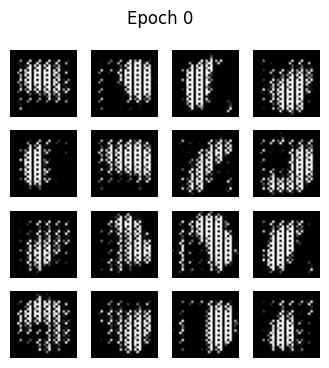

Epoch 2/500


100%|██████████| 469/469 [00:10<00:00, 43.96it/s]


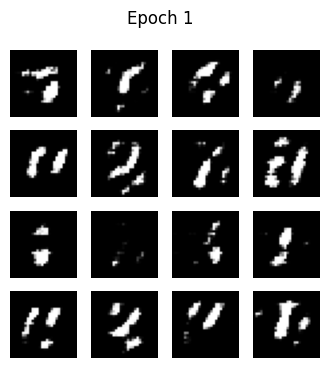

Epoch 3/500


100%|██████████| 469/469 [00:10<00:00, 43.50it/s]


Epoch 4/500


100%|██████████| 469/469 [00:11<00:00, 42.59it/s]


Epoch 5/500


...

100%|██████████| 469/469 [00:10<00:00, 42.94it/s]


Epoch 50/500


100%|██████████| 469/469 [00:11<00:00, 42.27it/s]


Epoch 51/500


100%|██████████| 469/469 [00:11<00:00, 42.54it/s]


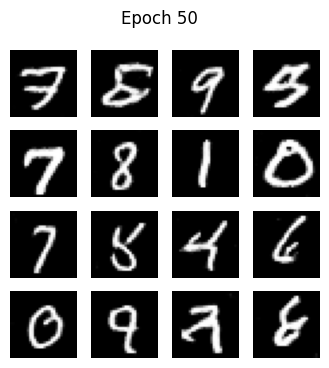

Epoch 52/500


100%|██████████| 469/469 [00:10<00:00, 42.98it/s]


Epoch 53/500


100%|██████████| 469/469 [00:10<00:00, 43.44it/s]


Epoch 54/500


...

100%|██████████| 469/469 [00:10<00:00, 43.29it/s]


Epoch 100/500


100%|██████████| 469/469 [00:10<00:00, 43.26it/s]


Epoch 101/500


100%|██████████| 469/469 [00:10<00:00, 43.27it/s]


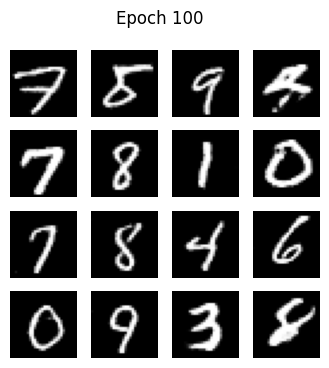

Epoch 102/500


100%|██████████| 469/469 [00:10<00:00, 43.28it/s]


Epoch 103/500


100%|██████████| 469/469 [00:10<00:00, 43.34it/s]


Epoch 104/500


...

100%|██████████| 469/469 [00:10<00:00, 43.23it/s]


Epoch 150/500


100%|██████████| 469/469 [00:10<00:00, 43.31it/s]


Epoch 151/500


100%|██████████| 469/469 [00:10<00:00, 43.30it/s]


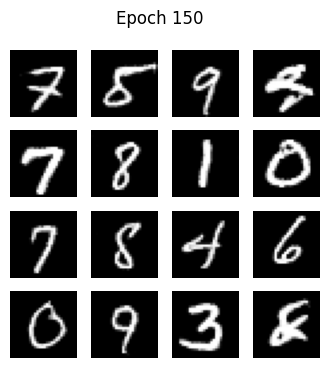

Epoch 152/500


100%|██████████| 469/469 [00:10<00:00, 43.27it/s]


Epoch 153/500


100%|██████████| 469/469 [00:10<00:00, 43.11it/s]


Epoch 154/500


...

100%|██████████| 469/469 [00:10<00:00, 43.36it/s]


Epoch 200/500


100%|██████████| 469/469 [00:10<00:00, 43.26it/s]


Epoch 201/500


100%|██████████| 469/469 [00:10<00:00, 43.17it/s]


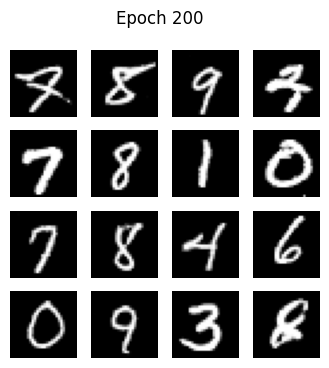

Epoch 202/500


100%|██████████| 469/469 [00:10<00:00, 43.19it/s]


Epoch 203/500


100%|██████████| 469/469 [00:20<00:00, 22.92it/s]


Epoch 204/500


...

100%|██████████| 469/469 [00:10<00:00, 43.29it/s]


Epoch 250/500


100%|██████████| 469/469 [00:11<00:00, 42.55it/s]


Epoch 251/500


100%|██████████| 469/469 [00:11<00:00, 41.72it/s]


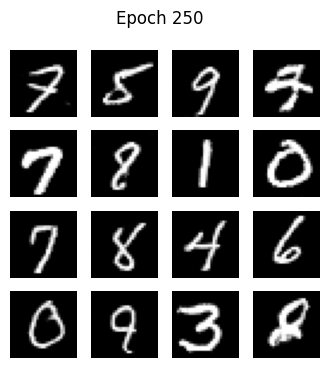

Epoch 252/500


100%|██████████| 469/469 [00:10<00:00, 42.78it/s]


Epoch 253/500


100%|██████████| 469/469 [00:10<00:00, 42.97it/s]


Epoch 254/500


...

100%|██████████| 469/469 [00:10<00:00, 43.30it/s]


Epoch 300/500


100%|██████████| 469/469 [00:10<00:00, 43.44it/s]


Epoch 301/500


100%|██████████| 469/469 [00:10<00:00, 43.85it/s]


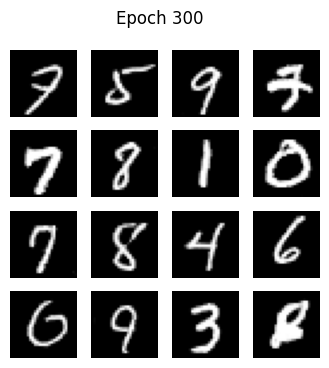

Epoch 302/500


100%|██████████| 469/469 [00:10<00:00, 43.82it/s]


Epoch 303/500


100%|██████████| 469/469 [00:10<00:00, 43.72it/s]


Epoch 304/500


...

100%|██████████| 469/469 [00:10<00:00, 43.35it/s]


Epoch 350/500


100%|██████████| 469/469 [00:10<00:00, 43.22it/s]


Epoch 351/500


100%|██████████| 469/469 [00:10<00:00, 43.16it/s]


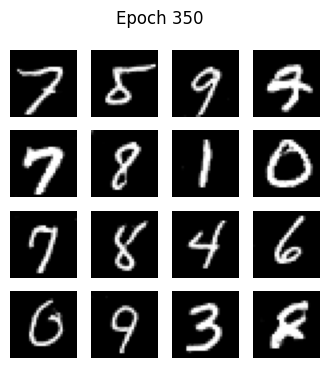

Epoch 352/500


100%|██████████| 469/469 [00:10<00:00, 43.19it/s]


Epoch 353/500


100%|██████████| 469/469 [00:10<00:00, 43.18it/s]


Epoch 354/500


...

100%|██████████| 469/469 [00:10<00:00, 43.39it/s]


Epoch 400/500


100%|██████████| 469/469 [00:10<00:00, 43.29it/s]


Epoch 401/500


100%|██████████| 469/469 [00:10<00:00, 43.41it/s]


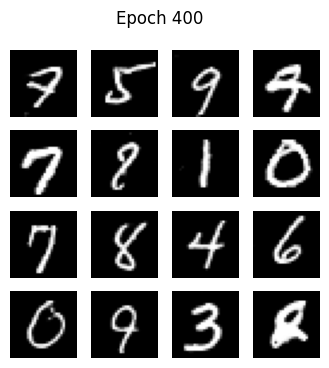

Epoch 402/500


100%|██████████| 469/469 [00:10<00:00, 43.40it/s]


Epoch 403/500


100%|██████████| 469/469 [00:10<00:00, 43.28it/s]


Epoch 404/500


...

100%|██████████| 469/469 [00:10<00:00, 43.24it/s]


Epoch 450/500


100%|██████████| 469/469 [00:10<00:00, 43.34it/s]


Epoch 451/500


100%|██████████| 469/469 [00:10<00:00, 43.09it/s]


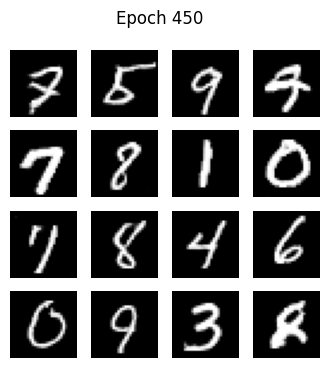

Epoch 452/500


100%|██████████| 469/469 [00:10<00:00, 43.17it/s]


Epoch 453/500


100%|██████████| 469/469 [00:10<00:00, 43.40it/s]


Epoch 454/500


...

100%|██████████| 469/469 [00:10<00:00, 43.45it/s]


Epoch 499/500


100%|██████████| 469/469 [00:10<00:00, 43.40it/s]


Epoch 500/500


100%|██████████| 469/469 [00:10<00:00, 43.24it/s]


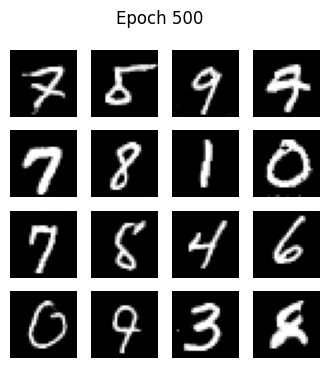

In [ ]:
from matplotlib import pyplot as plt
EPOCHS = 500
noise_dim = 100
num_examples_to_generate = 16

seed = tf.random.normal([num_examples_to_generate, noise_dim])
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4,4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.suptitle(f"Epoch {epoch}")
    plt.show()
def train(epochs):
  for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    for image_batch in tqdm(dataset):
      train_loop(image_batch)
    if epoch % 50 == 0 or epoch == 1:
       generate_and_save_images(generator, epoch, seed)
train(EPOCHS)
generate_and_save_images(generator,EPOCHS, seed)